# Notebook 01 — Exploratory Data Analysis

In this notebook, the SEC insider trading filings scraped earlier are explored. The goal is to get a feel for the data: how many filings per company, what trade types exist, which insiders are most active, and so on. The market and portfolio return data needed later for the event study are also downloaded here, and some basic cleaning/deduplication of the events is performed.

**Data sources:**
- `sec_filings.csv`: raw insider trading filings (scraped from SEC EDGAR)
- Yahoo Finance: for NASDAQ index returns and individual stock prices

**Outputs:**
- `market_returns.csv`: daily NASDAQ returns
- `portfolio_returns.csv`: daily returns for all stocks in the sample
- `managers.csv`: unique insider/manager records
- `unique_event_filings.csv`: deduplicated event filings
- `earnings_dates_cache.csv`: cached earnings call dates
- Various exploratory plots

## Read Filings

The raw SEC filings CSV is loaded and the columns and data types are inspected. This is just the standard "look at the data before doing anything else" step.

In [1]:
import pandas as pd

sec_filings = pd.read_csv('sec_filings.csv', sep=';', encoding='utf-8')
sec_filings.info()

<class 'pandas.DataFrame'>
RangeIndex: 717 entries, 0 to 716
Data columns (total 17 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   X             356 non-null    str    
 1   Filing Date   717 non-null    str    
 2   Trade Date    717 non-null    str    
 3   Ticker        717 non-null    str    
 4   Company Name  717 non-null    str    
 5   Insider Name  717 non-null    str    
 6   Title         717 non-null    str    
 7   Trade Type    717 non-null    str    
 8   Price         717 non-null    str    
 9   Qty           717 non-null    str    
 10  Owned         717 non-null    str    
 11  ΔOwn          717 non-null    str    
 12  Value         717 non-null    str    
 13  1d            0 non-null      float64
 14  1w            0 non-null      float64
 15  1m            0 non-null      float64
 16  6m            0 non-null      float64
dtypes: float64(4), str(13)
memory usage: 95.4 KB


In [2]:
sec_filings.columns

Index(['X', 'Filing Date', 'Trade Date', 'Ticker', 'Company Name',
       'Insider Name', 'Title', 'Trade Type', 'Price', 'Qty', 'Owned', 'ΔOwn',
       'Value', '1d', '1w', '1m', '6m'],
      dtype='str')

In [3]:
sec_filings.head()

,X,Filing Date,Trade Date,Ticker,Company Name,Insider Name,Title,Trade Type,Price,Qty,Owned,ΔOwn,Value,1d,1w,1m,6m
0,NaN,19.11.2024 18:30,18.11.2024,AAPL,Apple Inc.,Kondo Chris,Principal Accounting Officer,S - Sale,$228.87,"-4,13","15,419",-21%,"-$945,233",NaN,NaN,NaN,NaN
1,M,19.11.2024 18:31,15.11.2024,AAPL,Apple Inc.,Levinson Arthur D,Dir,S - Sale,$227.32,-200,"4,215,576",-5%,"-$45,464,500",NaN,NaN,NaN,NaN
2,NaN,18.12.2024 18:30,16.12.2024,AAPL,Apple Inc.,Williams Jeffrey E,COO,S - Sale,$249.97,-100,"389,944",-20%,"-$24,997,395",NaN,NaN,NaN,NaN
3,D,04.02.2025 18:33,03.02.2025,AAPL,Apple Inc.,Levinson Arthur D,Dir,S - Sale+OE,$226.35,"-1,516","4,215,576",0%,"-$343,147",NaN,NaN,NaN,NaN
4,D,03.04.2025 18:31,02.04.2025,AAPL,Apple Inc.,Adams Katherine L.,"SVP, GC, Secretary",S - Sale+OE,$223.67,"-38,822","179,158",-18%,"-$8,683,252",NaN,NaN,NaN,NaN


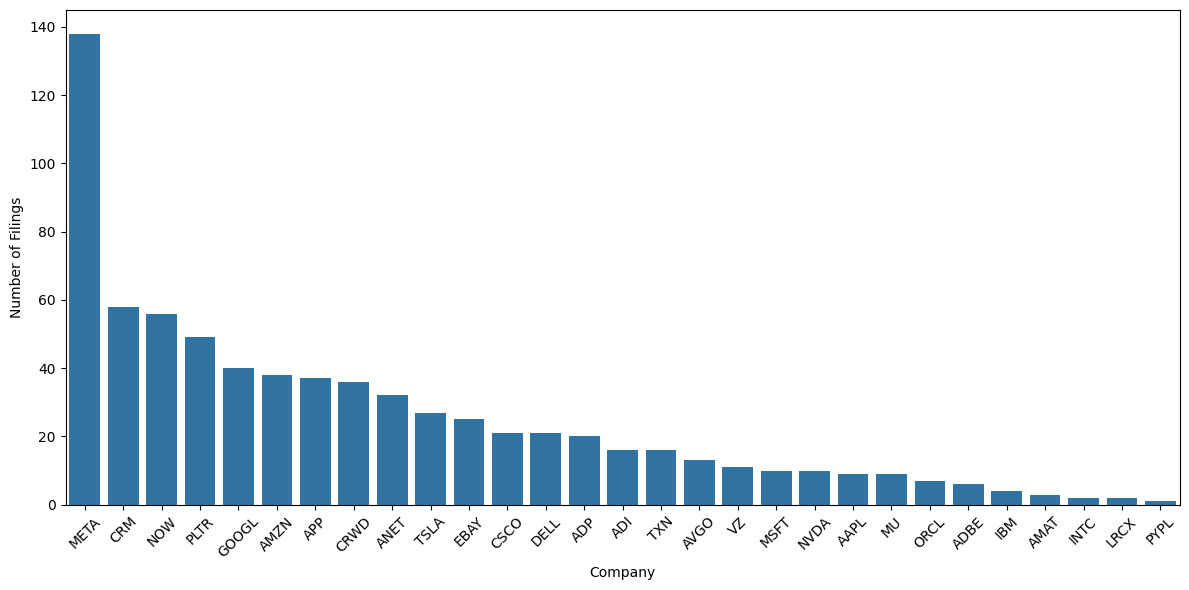

In [4]:
# Bar chart of the number of filings per company
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(12, 6))
sns.countplot(data=sec_filings, x='Ticker', order=sec_filings['Ticker'].value_counts().index)
plt.xticks(rotation=45)
plt.xlabel('Company')
plt.ylabel('Number of Filings')
plt.tight_layout()
plt.show()

In [5]:
# filter tickers for companies with 0 filings
tickers_with_filings = sec_filings['Ticker'].unique()
all_tickers = ["MSFT","NVDA","AAPL","AMZN","GOOGL","META","TSLA","AVGO","ORCL","PLTR","CRM","CRWD","ANET","APP","INTC","IBM", "ADBE","PYPL","NOW", "CSCO","DELL","MU",  "ADP", "TXN", "AMAT","VMW", "EBAY","ADI", "LRCX","VZ"]
missing_tickers = [ticker for ticker in all_tickers if ticker not in tickers_with_filings]
print("Tickers with no filings:", missing_tickers)

Tickers with no filings: ['VMW']


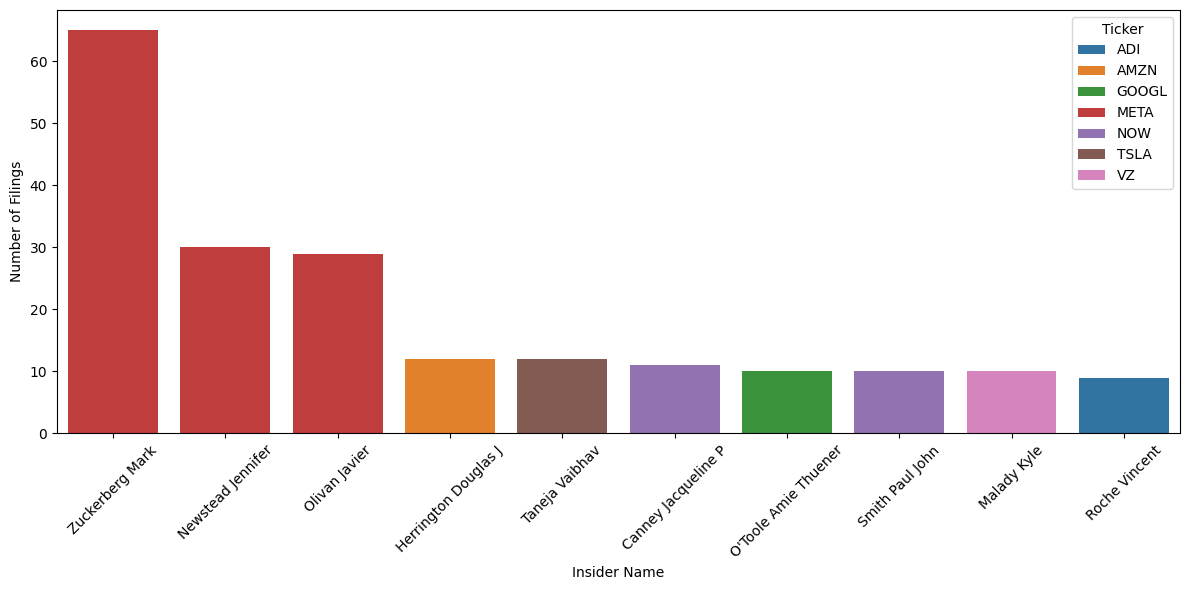

In [6]:
# bar chart of the number of filings per insider Name top 10, colored by Ticker, ordered descending
plt.figure(figsize=(12, 6))
top10_names = sec_filings['Insider Name'].value_counts().head(10).index
top10_counts = sec_filings['Insider Name'].value_counts().loc[top10_names]
ordered_names = top10_counts.sort_values(ascending=False).index
sns.countplot(
    data=sec_filings[sec_filings['Insider Name'].isin(top10_names)],
    x='Insider Name',
    hue='Ticker',
    order=ordered_names
)
plt.xlabel('Insider Name')
plt.ylabel('Number of Filings')
plt.xticks(rotation=45)
plt.legend(title='Ticker')
plt.tight_layout()
plt.show()

Trade Type
S - Sale        391
S - Sale+OE     314
P - Purchase     12
Name: count, dtype: int64


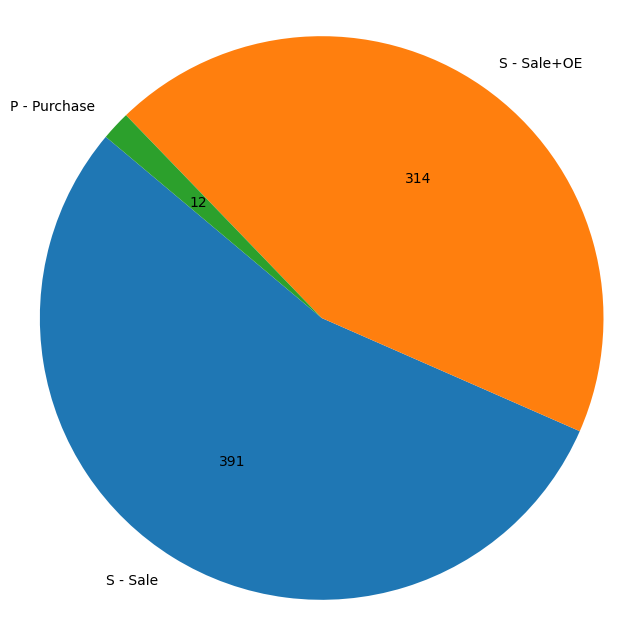

In [7]:
# pie chart of trade types
plt.figure(figsize=(8, 8))
trade_type_counts = sec_filings['Trade Type'].value_counts()
print(trade_type_counts)
plt.pie(trade_type_counts, labels=trade_type_counts.index, autopct=lambda p: f'{int(round(p/100 * sum(trade_type_counts)))}', startangle=140)
plt.axis('equal')
plt.show()

The dataset is heavily dominated by selling activity: 391 Sale and 314 Sale+OE filings versus only 12 Purchases. This is fairly typical for large-cap tech companies where executives routinely liquidate equity compensation. The bar chart above also shows that filing activity is concentrated in a handful of tickers (PLTR, META, APP), while some companies have very few filings. VMW is the only ticker from the initial list with zero data, as the stock was delisted following the Broadcom acquisition. The top-10 most active insiders are almost exclusively from these high-activity firms.

# Unique Events

Here the number of distinct trading events is determined by grouping on (Trade Date, Ticker). Some dates have multiple trade types for the same company (e.g., both a Sale and a Sale+OE), which needs to be handled carefully later. The heatmap below visualizes where these overlapping trade types occur.

In [8]:
# number of unique events
event_set = sec_filings[['Trade Date', 'Ticker']].drop_duplicates()
len(event_set)

500

In [9]:
type_counts = sec_filings.groupby(['Trade Date', 'Ticker'])['Trade Type'].nunique().reset_index()

# filter for combinations with more than 1 unique Trade Type
multi_type = type_counts[type_counts['Trade Type'] > 1]

# merge with original DataFrame to get the relevant rows
result = pd.merge(
    sec_filings,
    multi_type[['Trade Date', 'Ticker']],
    on=['Trade Date', 'Ticker'],
    how='inner'
)

print(result)

       X       Filing Date  Trade Date Ticker                Company Name  \
0      D  28.01.2025 16:58  28.01.2025   ADBE                  Adobe Inc.   
1    NaN  30.01.2025 19:45  28.01.2025   ADBE                  Adobe Inc.   
2    NaN  04.11.2024 16:49  01.11.2024    ADI          Analog Devices Inc   
3      D  05.11.2024 17:00  01.11.2024    ADI          Analog Devices Inc   
4    NaN  06.03.2025 16:28  05.03.2025    ADI          Analog Devices Inc   
..   ...               ...         ...    ...                         ...   
135    M  22.05.2025 20:23  20.05.2025   PLTR  Palantir Technologies Inc.   
136    M  22.05.2025 20:25  20.05.2025   PLTR  Palantir Technologies Inc.   
137    D  08.11.2024 16:33  06.11.2024    TXN       Texas Instruments Inc   
138    D  08.11.2024 16:36  06.11.2024    TXN       Texas Instruments Inc   
139  NaN  08.11.2024 16:42  06.11.2024    TXN       Texas Instruments Inc   

           Insider Name                        Title    Trade Type    Price

In [10]:
result['Trade Date'].nunique()

34

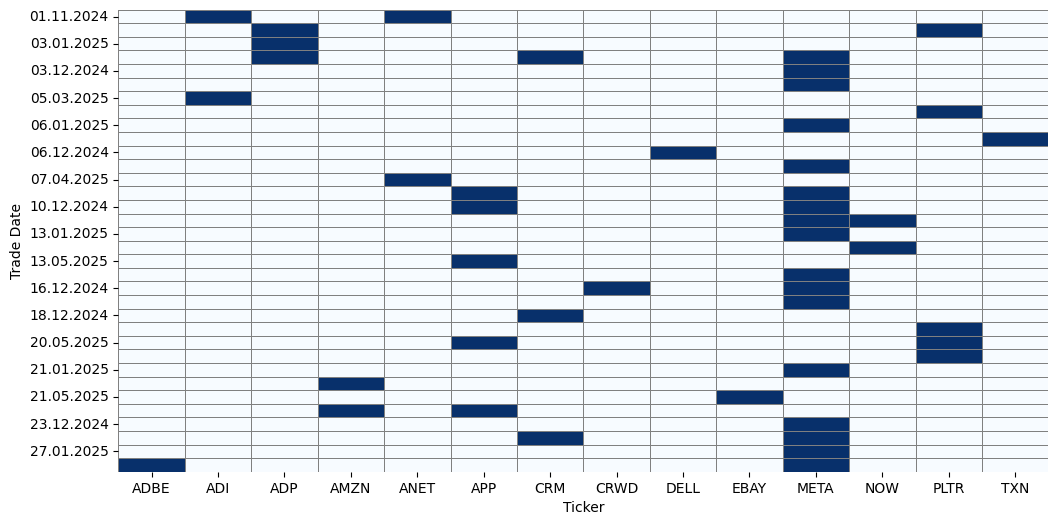

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# create a pivot table indicating multiple trade types
pivot = result.pivot_table(
    index='Trade Date',
    columns='Ticker',
    values='Trade Type',
    aggfunc=lambda x: x.nunique()
)

# set everything below 2 to 0 (only show where multiple types happened)
pivot = pivot.map(lambda x: 1 if x >= 2 else 0)

plt.figure(figsize=(12, 6))
sns.heatmap(pivot, cmap="Blues", cbar=False, linewidths=.5, linecolor='gray')
plt.xlabel('Ticker')
plt.ylabel('Trade Date')
plt.show()

In [12]:
sec_filings['Trade Type Cleaned'] = sec_filings['Trade Type'].apply(
    lambda x: 'S - Sale' if x == 'S - Sale+OE' else x
)

In [13]:
type_counts = sec_filings.groupby(['Trade Date', 'Ticker'])['Trade Type Cleaned'].nunique().reset_index()

# filter for combinations with more than 1 unique Trade Type
multi_type = type_counts[type_counts['Trade Type Cleaned'] > 1]

# merge with original DataFrame to get the relevant rows
result = pd.merge(
    sec_filings,
    multi_type[['Trade Date', 'Ticker']],
    on=['Trade Date', 'Ticker'],
    how='inner'
)

print(result)

     X       Filing Date  Trade Date Ticker Company Name    Insider Name  \
0    D  28.01.2025 16:58  28.01.2025   ADBE   Adobe Inc.  Forusz Jillian   
1  NaN  30.01.2025 19:45  28.01.2025   ADBE   Adobe Inc.   Ricks David A   

      Title    Trade Type    Price   Qty  Owned  ΔOwn      Value  1d  1w  1m  \
0  SVP, CAO   S - Sale+OE  $435.83  -334  2,685  -11%  -$145,567 NaN NaN NaN   
1       Dir  P - Purchase  $443.98  2,25  8,897   34%  +$998,946 NaN NaN NaN   

   6m Trade Type Cleaned  
0 NaN           S - Sale  
1 NaN       P - Purchase  


Out of 500 unique (Trade Date, Ticker) combinations, 34 dates have multiple trade types for the same company. However, once "S - Sale+OE" is treated as a variant of "S - Sale", only a single date remains with genuinely conflicting trade types: ADBE on 2025-01-28, where both a Sale+OE and a Purchase occurred. This means the conflict event handling in later notebooks mostly affects cases where the same day has both a Sale and a Sale+OE filing for the same company.

## Market Data

The NASDAQ Composite Index (^IXIC) is downloaded as the market benchmark. The daily percentage change gives the market return series that will be used in the market model estimation later. `auto_adjust=True` is set so that Yahoo Finance returns split- and dividend-adjusted close prices right away.

In [14]:
import yfinance as yf
nasdaq = yf.download("^IXIC", start="2023-12-01", end="2025-05-31", progress=False, auto_adjust=True) # auto_adjust=True ensures that we get adjusted close prices

nasdaq = nasdaq.reset_index()

# get market returns
nasdaq['market_return'] = nasdaq['Close'].pct_change()
market_returns = nasdaq[['Date', 'market_return']].rename(columns={"Date": "date"})
market_returns = market_returns.dropna()

print(market_returns.head())
market_returns.to_csv('market_returns.csv', index=False)

Price        date market_return
Ticker                         
1      2023-12-04     -0.008357
2      2023-12-05      0.003131
3      2023-12-06     -0.005847
4      2023-12-07      0.013663
5      2023-12-08      0.004462


## Portfolio Returns

Same idea as above, but now for every individual stock in the sample. Adjusted close prices are downloaded from Yahoo Finance and daily returns are computed. These per-stock returns are what gets regressed against the market returns to obtain the alpha and beta estimates.

In [15]:
import yfinance as yf
# download the data from Yahoo Finance for each stock in the portfolio
portfolio = ["MSFT","NVDA","AAPL","AMZN","GOOGL","META","TSLA","AVGO","ORCL","PLTR","CRM","CRWD","ANET","APP","INTC","IBM", "ADBE","PYPL","NOW", "CSCO","DELL","MU",  "ADP", "TXN", "AMAT","VMW", "EBAY","ADI", "LRCX","VZ"]
data = yf.download(portfolio, start="2023-12-01", end="2025-05-31", progress=False, auto_adjust=True)
# calculate daily returns
data = data['Close'].pct_change().reset_index().rename(columns={"Date": "date"})

data.head()
data.to_csv('portfolio_returns.csv', index=False)

$VMW: possibly delisted; no price data found  (1d 2023-12-01 -> 2025-05-31) (Yahoo error = "No data found, symbol may be delisted")

1 Failed download:
['VMW']: possibly delisted; no price data found  (1d 2023-12-01 -> 2025-05-31) (Yahoo error = "No data found, symbol may be delisted")


As expected, VMW returns no data since the stock was delisted. The remaining 29 tickers cover the period from December 2023 through May 2025, providing enough history for the 200-day estimation windows that start around mid-2024.

## Prepare and Clean Data

A clean list of unique insiders (name + title + company) is extracted and saved. This comes in handy later when looking up who's who.

In [16]:
managers_df = sec_filings[['Ticker','Company Name', 'Insider Name', 'Title']].copy().drop_duplicates()
managers_df.to_csv('managers.csv', index=False)
managers_df.head()

,Ticker,Company Name,Insider Name,Title
0,AAPL,Apple Inc.,Kondo Chris,Principal Accounting Officer
1,AAPL,Apple Inc.,Levinson Arthur D,Dir
2,AAPL,Apple Inc.,Williams Jeffrey E,COO
4,AAPL,Apple Inc.,Adams Katherine L.,"SVP, GC, Secretary"
5,AAPL,Apple Inc.,Cook Timothy D,CEO


## Sample Overview Visualizations

These are the plots used in the final report to describe the sample. A consistent plot style (serif font, white grid, etc.) is set up and the following are produced:

- **Temporal distribution** of filings over time, with earnings seasons shaded
- **Event distribution by firm** (Pareto-style, showing which companies drive most of the events)
- **Trading volume by firm** same Pareto idea but in dollar terms
- **Stock price charts** for the top-3 most active tickers, overlaid with insider trade markers and earnings call dates

The 80/20 Pareto lines help illustrate how concentrated the activity is across firms.

In [17]:
import pathlib
import matplotlib.ticker as mtick
import numpy as np
import pandas as pd

sns.set_theme(style="whitegrid", context="paper", font_scale=1.3)
plt.rcParams.update({
    "font.family": "serif",
    "mathtext.fontset": "stix",
    "axes.titlesize": 14,
    "axes.labelsize": 14,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 11,
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
})

DATA = pathlib.Path(".")
FIG = pathlib.Path("./figures")
FIG.mkdir(exist_ok=True)

EVENT_COLORS = {
    "P - Purchase": "#009E73",
    "S - Sale": "#0072B2",
    "S - Sale+OE": "#E69F00",
}
EVENT_ORDER = ["P - Purchase", "S - Sale", "S - Sale+OE"]

meta = pd.read_csv(DATA / "event_study_metadata.csv", parse_dates=["event_date"])
print(f"Loaded {len(meta)} events from metadata")

Loaded 492 events from metadata


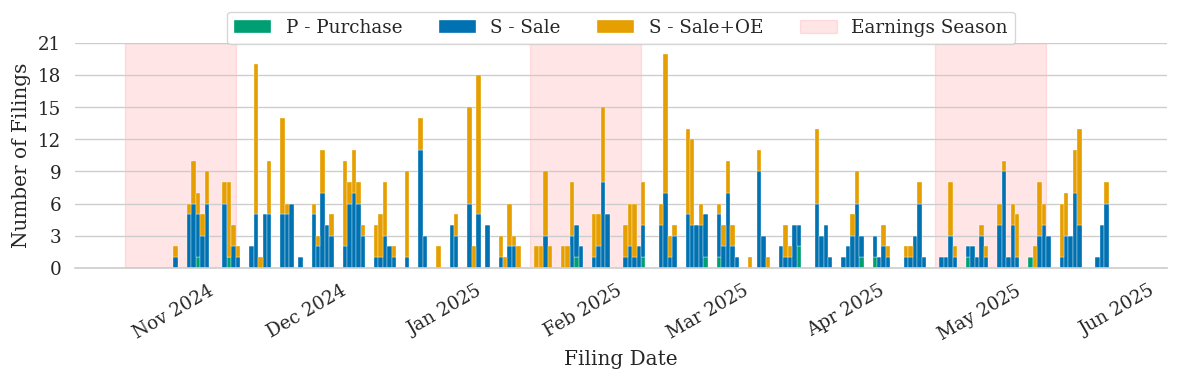

In [18]:
# Temporal Distribution of Directors' Dealings
filings_raw = pd.read_csv(DATA / "sec_filings.csv", sep=";", encoding="utf-8-sig")
filings_raw["filing_date"] = pd.to_datetime(
    filings_raw["Filing Date"].str.split(" ").str[0], format="%d.%m.%Y"
)
filings_raw = filings_raw[
    (filings_raw["filing_date"] >= "2024-11-01")
    & (filings_raw["filing_date"] <= "2025-05-31")
]

fig, ax = plt.subplots(figsize=(10, 3.5))

bins = pd.date_range("2024-11-01", "2025-06-01", freq="D")

ax.hist(
    [filings_raw.loc[filings_raw["Trade Type"] == et, "filing_date"] for et in EVENT_ORDER],
    bins=bins,
    stacked=True,
    color=[EVENT_COLORS[et] for et in EVENT_ORDER],
    label=EVENT_ORDER,
    edgecolor="white",
    linewidth=0.2,
)

# shade approximate earnings seasons
earnings_seasons = [
    ("2024-10-21", "2024-11-15"),  # Q3 2024
    ("2025-01-20", "2025-02-14"),  # Q4 2024
    ("2025-04-21", "2025-05-16"),  # Q1 2025
]
for i, (start, end) in enumerate(earnings_seasons):
    ax.axvspan(pd.Timestamp(start), pd.Timestamp(end),
               alpha=0.10, color="red", zorder=0,
               label="Earnings Season" if i == 0 else None)

ax.set_xlabel("Filing Date", fontsize=12)
ax.set_ylabel("Number of Filings", fontsize=12)
ax.yaxis.set_major_locator(mtick.MaxNLocator(integer=True))
ax.tick_params(axis="both", labelsize=11)
ax.grid(axis="x", visible=False)
ax.legend(
    ncol=4, fontsize=11, loc="upper center",
    bbox_to_anchor=(0.5, 1.18), frameon=True,
)
ax.xaxis.set_major_locator(plt.matplotlib.dates.MonthLocator())
ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter("%b %Y"))
ax.tick_params(axis="x", rotation=30)
sns.despine(left=True)
fig.tight_layout()
fig.savefig(FIG / "fig0_temporal_distribution.png", bbox_inches="tight")
plt.show()

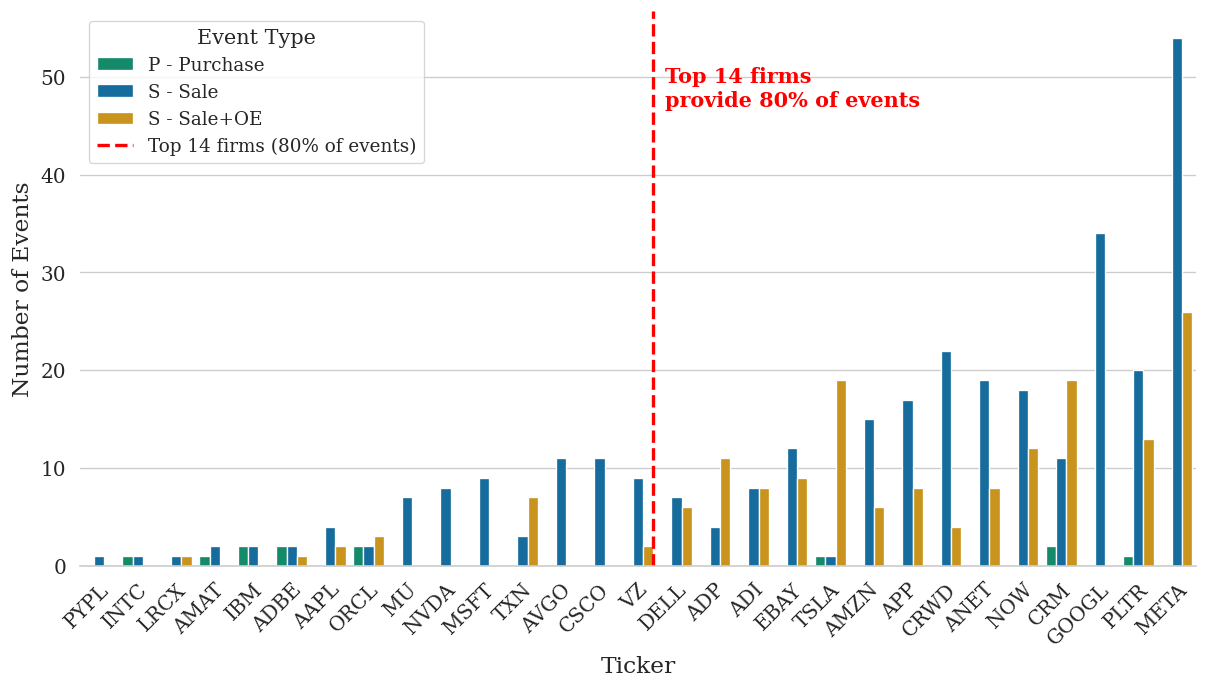

In [19]:
# fig 1: Event Distribution by Firm and Type
counts = (
    meta.groupby(["ticker", "event_type"])
    .size()
    .reset_index(name="count")
)

ticker_totals = counts.groupby("ticker")["count"].sum().sort_values(ascending=True)
total_events = ticker_totals.sum()
n_tickers = len(ticker_totals)

cumulative_from_right = ticker_totals[::-1].cumsum()
n_companies = (cumulative_from_right <= 0.8 * total_events).sum() + 1

line_pos = n_tickers - n_companies - 0.6
ticker_order = ticker_totals.index.tolist()

fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(
    data=counts,
    x="ticker",
    y="count",
    hue="event_type",
    hue_order=EVENT_ORDER,
    palette=EVENT_COLORS,
    order=ticker_order,
    ax=ax,
)

ax.axvline(x=line_pos, color="red", linestyle="--", lw=2,
           label=f"Top {n_companies} firms (80% of events)")

ax.text(line_pos + 0.3, ax.get_ylim()[1] * 0.9,
        f'Top {n_companies} firms\nprovide 80% of events',
        color='red', fontweight='bold',
        verticalalignment='top', horizontalalignment='left')

ax.tick_params(axis='x', rotation=45)
plt.setp(ax.get_xticklabels(), ha="right", rotation_mode="anchor")

ax.set_xlabel("Ticker")
ax.set_ylabel("Number of Events")
ax.legend(title="Event Type", loc='upper left')

sns.despine(left=True)
fig.savefig(FIG / "fig1_event_distribution_pareto.png", bbox_inches="tight")
plt.show()

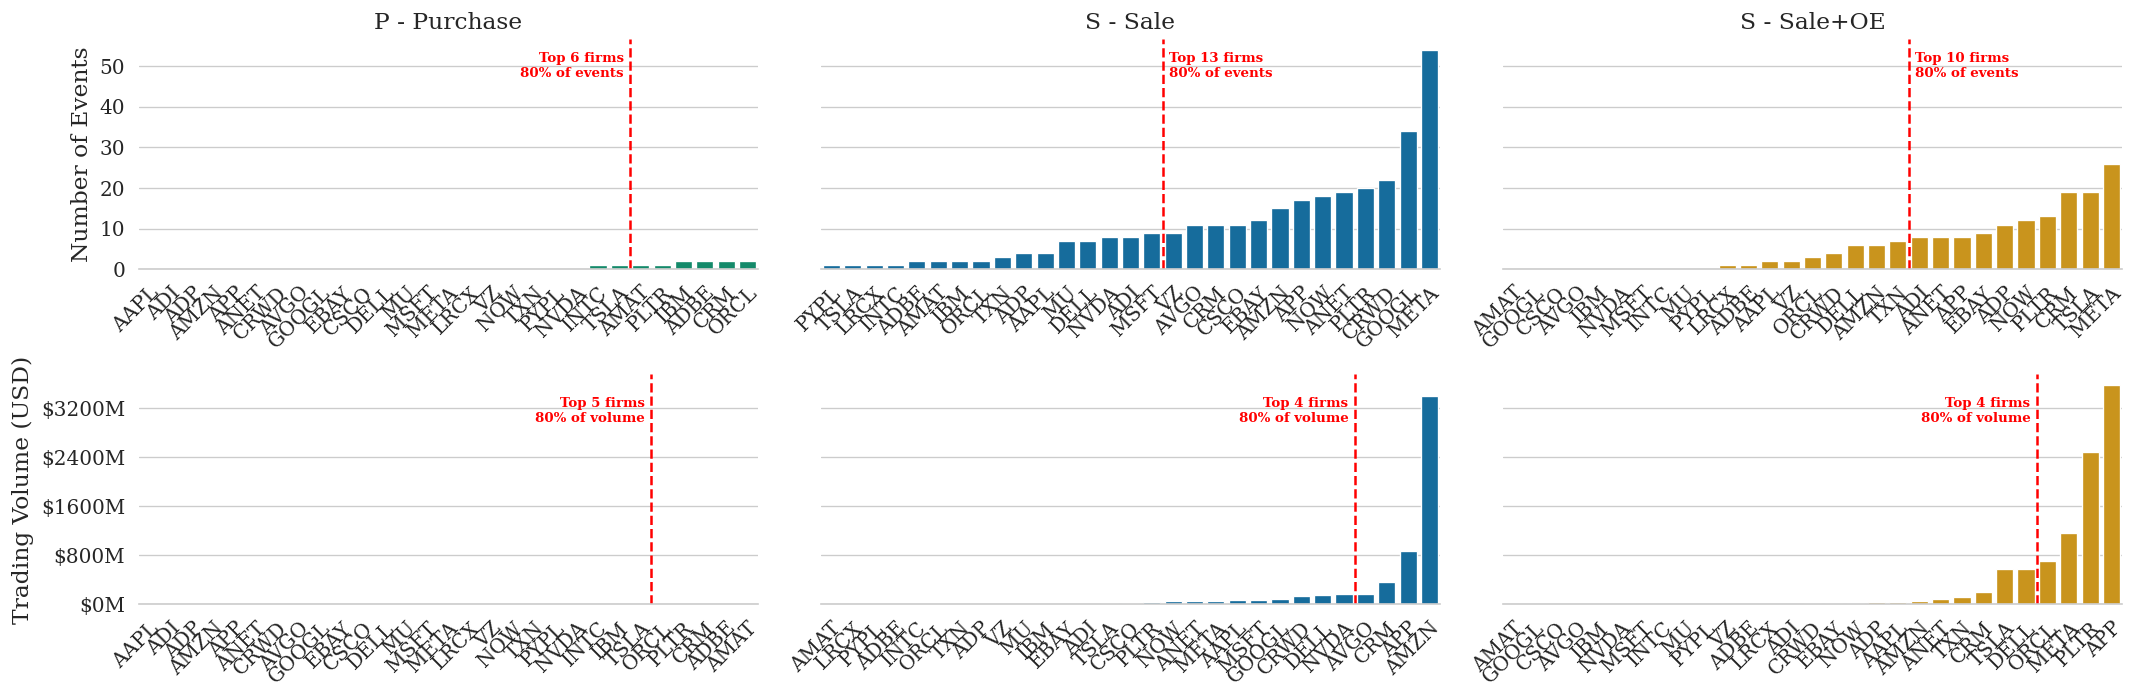

In [20]:
# fig 1 (combined): Event Count & Trading Volume by Firm - Split by Event Type 

# top row (event counts)
counts = (
    meta.groupby(["ticker", "event_type"])
    .size()
    .reset_index(name="count")
)
all_tickers_evt = meta["ticker"].unique()
global_ymax_evt = counts["count"].max() * 1.1

# bottom row (trading volume)
filings = pd.read_csv(DATA / "sec_filings.csv", sep=";", encoding="utf-8-sig")
filings["abs_value"] = (
    filings["Value"]
    .str.replace("$", "", regex=False)
    .str.replace(",", "", regex=False)
    .astype(float)
    .abs()
)
vol = (
    filings.groupby(["Ticker", "Trade Type"])["abs_value"]
    .sum()
    .reset_index(name="total_volume")
)
all_tickers_vol = filings["Ticker"].unique()
global_ymax_vol = vol["total_volume"].max() * 1.1

fig, axes = plt.subplots(2, 3, figsize=(18, 6), sharey="row")

for col_idx, event_type in enumerate(EVENT_ORDER):
    # top row
    ax_top = axes[0, col_idx]

    subset = counts[counts["event_type"] == event_type].copy()
    subset = (
        subset.set_index("ticker")["count"]
        .reindex(all_tickers_evt, fill_value=0)
        .reset_index()
        .rename(columns={"index": "ticker"})
    )
    ticker_totals = subset.groupby("ticker")["count"].sum().sort_values(ascending=True)
    ticker_order = ticker_totals.index.tolist()

    nonzero = ticker_totals[ticker_totals > 0]
    cum = nonzero[::-1].cumsum()
    n_co = (cum <= 0.8 * nonzero.sum()).sum() + 1
    lp = len(ticker_totals) - n_co - 0.5

    sns.barplot(data=subset, x="ticker", y="count",
                color=EVENT_COLORS[event_type], order=ticker_order, ax=ax_top)
    ax_top.axvline(x=lp, color="red", linestyle="--", lw=1.5)
    ha = "left" if lp < len(ticker_totals) * 0.75 else "right"
    ax_top.text(lp + (0.3 if ha == "left" else -0.3), global_ymax_evt * 0.9,
                f'Top {n_co} firms\n80% of events', color='red', fontweight='bold',
                va='top', ha=ha, fontsize=8)
    ax_top.tick_params(axis='x', rotation=45)
    plt.setp(ax_top.get_xticklabels(), ha="right", rotation_mode="anchor")
    ax_top.set_xlabel("")
    ax_top.yaxis.set_major_locator(mtick.MaxNLocator(nbins=7))
    ax_top.set_title(event_type)
    sns.despine(ax=ax_top, left=True)

    # bottom row
    ax_bot = axes[1, col_idx]

    sub_vol = vol[vol["Trade Type"] == event_type].copy()
    sub_vol = (
        sub_vol.set_index("Ticker")["total_volume"]
        .reindex(all_tickers_vol, fill_value=0)
        .reset_index()
        .rename(columns={"index": "Ticker"})
    )
    tt_vol = sub_vol.groupby("Ticker")["total_volume"].sum().sort_values(ascending=True)
    tt_order = tt_vol.index.tolist()

    nz_vol = tt_vol[tt_vol > 0]
    cum_vol = nz_vol[::-1].cumsum()
    n_co_v = (cum_vol <= 0.8 * nz_vol.sum()).sum() + 1
    lp_v = len(tt_vol) - n_co_v - 0.5

    sns.barplot(data=sub_vol, x="Ticker", y="total_volume",
                color=EVENT_COLORS[event_type], order=tt_order, ax=ax_bot)
    ax_bot.axvline(x=lp_v, color="red", linestyle="--", lw=1.5)
    ha_v = "left" if lp_v < len(tt_vol) * 0.75 else "right"
    ax_bot.text(lp_v + (0.3 if ha_v == "left" else -0.3), global_ymax_vol * 0.86,
                f'Top {n_co_v} firms\n80% of volume', color='red', fontweight='bold',
                va='top', ha=ha_v, fontsize=8)
    ax_bot.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"${x/1e6:.0f}M"))
    ax_bot.yaxis.set_major_locator(mtick.MaxNLocator(nbins=6))
    ax_bot.tick_params(axis='x', rotation=45)
    plt.setp(ax_bot.get_xticklabels(), ha="right", rotation_mode="anchor")
    ax_bot.set_xlabel("")
    ax_bot.set_title("")
    sns.despine(ax=ax_bot, left=True)

axes[0, 0].set_ylabel("Number of Events")
axes[1, 0].set_ylabel("Trading Volume (USD)")
for c in range(1, 3):
    axes[0, c].set_ylabel("")
    axes[1, c].set_ylabel("")

plt.tight_layout()
fig.savefig(FIG / "fig1_pareto_split_combined.png", bbox_inches="tight")
plt.show()

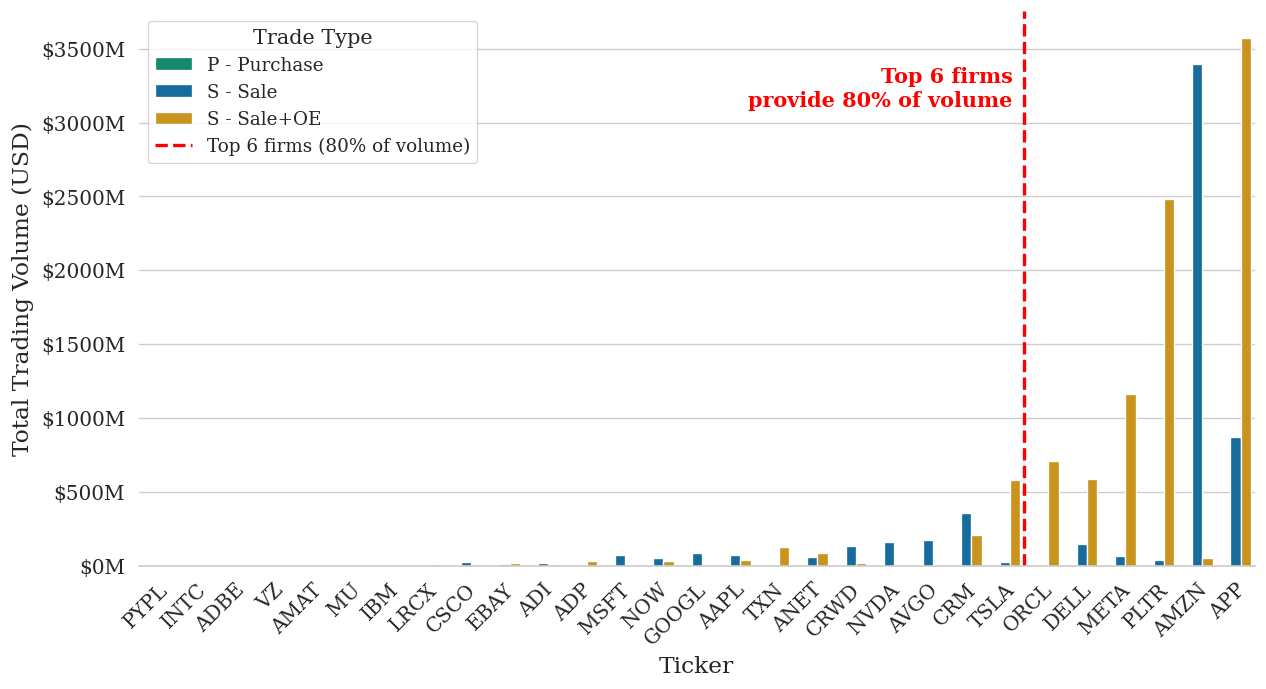

In [21]:
# fig 1b: Total Trading Volume by Firm (Pareto, Vertical Bars)
filings = pd.read_csv(DATA / "sec_filings.csv", sep=";", encoding="utf-8-sig")
filings["abs_value"] = (
    filings["Value"]
    .str.replace("$", "", regex=False)
    .str.replace(",", "", regex=False)
    .astype(float)
    .abs()
)

vol = (
    filings.groupby(["Ticker", "Trade Type"])["abs_value"]
    .sum()
    .reset_index(name="total_volume")
)

ticker_totals_vol = (
    vol.groupby("Ticker")["total_volume"]
    .sum()
    .sort_values(ascending=True)
)
vol_order = ticker_totals_vol.index.tolist()

total_volume = ticker_totals_vol.sum()
n_tickers_vol = len(ticker_totals_vol)

cumulative_from_right = ticker_totals_vol[::-1].cumsum()
n_companies_vol = (cumulative_from_right <= 0.8 * total_volume).sum() + 1

line_pos_vol = n_tickers_vol - n_companies_vol - 0.5

fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(
    data=vol,
    x="Ticker",
    y="total_volume",
    hue="Trade Type",
    hue_order=EVENT_ORDER,
    palette=EVENT_COLORS,
    order=vol_order,
    ax=ax,
)

ax.axvline(x=line_pos_vol, color="red", linestyle="--", lw=2,
           label=f"Top {n_companies_vol} firms (80% of volume)")

ax.text(line_pos_vol - 0.3, ax.get_ylim()[1] * 0.9,
        f'Top {n_companies_vol} firms\nprovide 80% of volume',
        color='red', fontweight='bold',
        verticalalignment='top', horizontalalignment='right')

ax.tick_params(axis='x', rotation=45)
plt.setp(ax.get_xticklabels(), ha="right", rotation_mode="anchor")

ax.set_xlabel("Ticker")
ax.set_ylabel("Total Trading Volume (USD)")
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"${x/1e6:.0f}M"))

ax.legend(title="Trade Type", loc='upper left')

sns.despine(left=True)
fig.savefig(FIG / "fig1b_trading_volume_pareto.png", bbox_inches="tight")
plt.show()

Top 3 by event count: ['META', 'CRM', 'NOW']
  META: 137 events — {'S - Sale+OE': 77, 'S - Sale': 60}
  CRM: 58 events — {'S - Sale+OE': 42, 'S - Sale': 14, 'P - Purchase': 2}
  NOW: 56 events — {'S - Sale+OE': 32, 'S - Sale': 24}


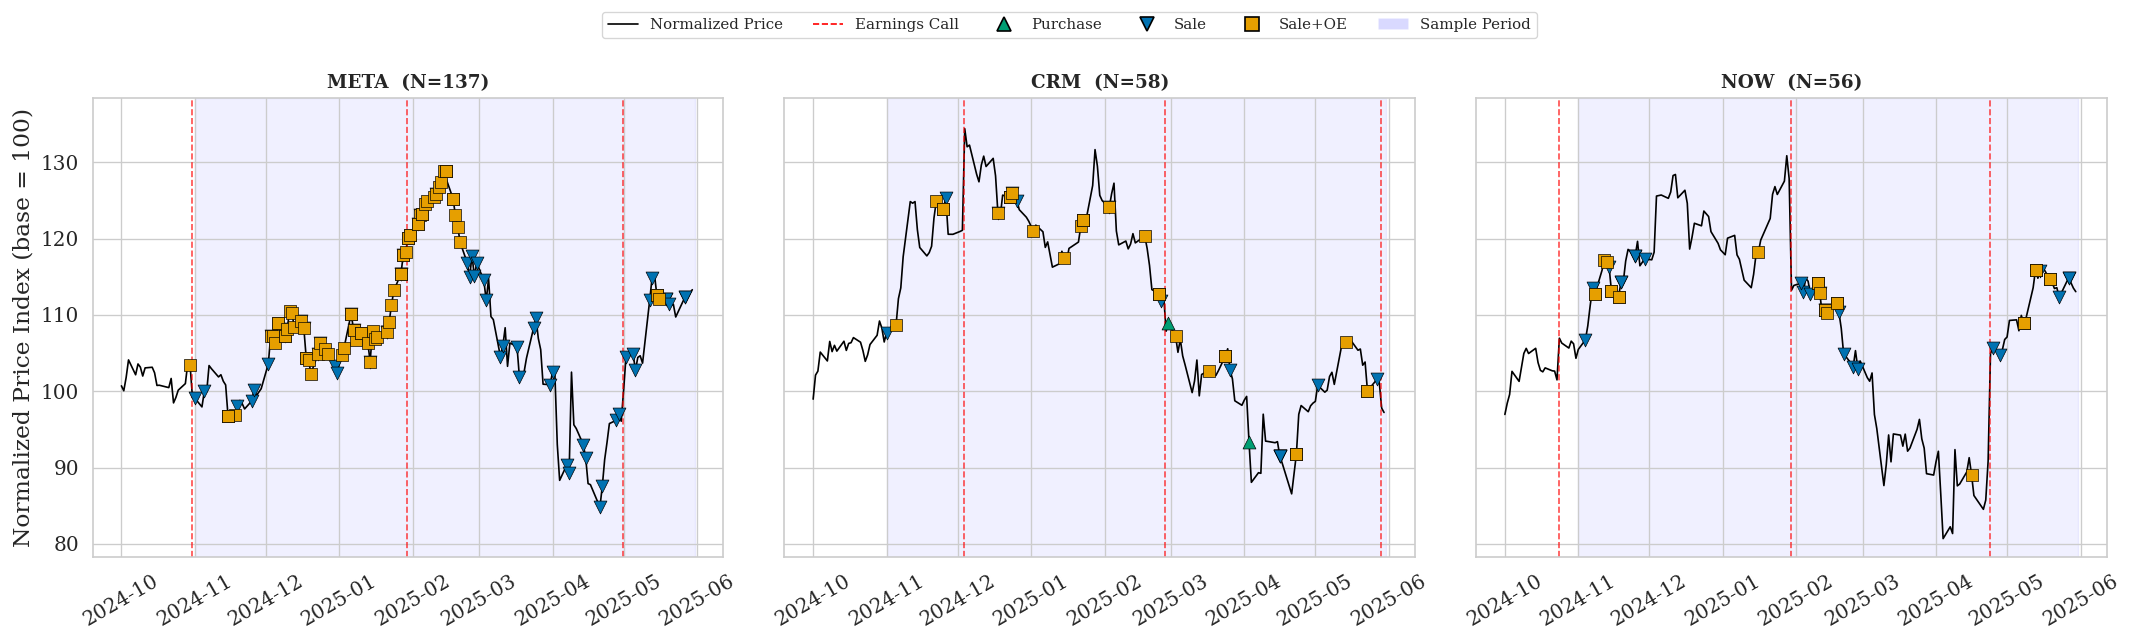

In [22]:
# fig 1c: Stock Price with Insider Trades & Earnings Calls
from matplotlib.lines import Line2D

filings_raw = pd.read_csv(DATA / "sec_filings.csv", sep=";", encoding="utf-8-sig")
filings_raw["abs_value"] = (
    filings_raw["Value"]
    .str.replace("$", "", regex=False)
    .str.replace(",", "", regex=False)
    .astype(float)
    .abs()
)
filings_raw["trade_date"] = pd.to_datetime(filings_raw["Trade Date"], format="%d.%m.%Y")

sample_filings = filings_raw[
    (filings_raw["trade_date"] >= "2024-11-01") & (filings_raw["trade_date"] <= "2025-05-31")
]
top3 = sample_filings["Ticker"].value_counts().head(3).index.tolist()
print(f"Top 3 by event count: {top3}")
for t in top3:
    n = (sample_filings["Ticker"] == t).sum()
    by_type = dict(sample_filings[sample_filings["Ticker"] == t]["Trade Type"].value_counts())
    print(f"  {t}: {n} events — {by_type}")

port_df = pd.read_csv(DATA / "portfolio_returns.csv", parse_dates=["date"])
port_df = port_df[port_df["date"] >= "2024-10-01"].copy()

earn_df = pd.read_csv(DATA / "earnings_dates_cache.csv", parse_dates=["earnings_date"])
earn_df = earn_df[(earn_df["earnings_date"] >= "2024-10-01") & (earn_df["earnings_date"] <= "2025-06-01")]

SAMPLE_START = pd.Timestamp("2024-11-01")
SAMPLE_END = pd.Timestamp("2025-05-31")

TRADE_MARKERS = {
    "P - Purchase": {"marker": "^", "color": "#009E73", "label": "Purchase"},
    "S - Sale":     {"marker": "v", "color": "#0072B2", "label": "Sale"},
    "S - Sale+OE":  {"marker": "s", "color": "#E69F00", "label": "Sale+OE"},
}

all_prices = {}
for ticker in top3:
    if ticker not in port_df.columns:
        continue
    p = port_df[["date", ticker]].dropna().copy()
    p["price_idx"] = (1 + p[ticker]).cumprod() * 100
    all_prices[ticker] = p

y_min = min(p["price_idx"].min() for p in all_prices.values()) * 0.97
y_max = max(p["price_idx"].max() for p in all_prices.values()) * 1.03

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

for ax, ticker in zip(axes, top3):
    prices = all_prices[ticker]

    ax.plot(prices["date"], prices["price_idx"], color="black", linewidth=1, zorder=1)
    ax.set_ylim(y_min, y_max)

    ax.axvspan(SAMPLE_START, SAMPLE_END, alpha=0.06, color="blue", zorder=0)

    tk_earnings = earn_df[earn_df["ticker"] == ticker]["earnings_date"]
    for edate in tk_earnings:
        ax.axvline(edate, color="red", linewidth=1, linestyle="--", alpha=0.7, zorder=2)

    tk_trades = filings_raw[filings_raw["Ticker"] == ticker]
    for etype, style in TRADE_MARKERS.items():
        sub = tk_trades[tk_trades["Trade Type"] == etype]
        if sub.empty:
            continue
        for _, trade in sub.iterrows():
            td = trade["trade_date"]
            closest = prices.iloc[(prices["date"] - td).abs().argsort()[:1]]
            if closest.empty:
                continue
            y_val = closest["price_idx"].iloc[0]
            ax.scatter(
                td, y_val,
                marker=style["marker"], color=style["color"],
                s=60, edgecolors="black", linewidth=0.4, zorder=3,
            )

    n_events = (sample_filings["Ticker"] == ticker).sum()
    ax.set_title(f"{ticker}  (N={n_events})", fontsize=11, fontweight="bold")
    ax.tick_params(axis="x", rotation=30)

axes[0].set_ylabel("Normalized Price Index (base = 100)")

legend_handles = [
    Line2D([0], [0], color="black", linewidth=1, label="Normalized Price"),
    Line2D([0], [0], color="red", linewidth=1, linestyle="--", label="Earnings Call"),
]
for etype, style in TRADE_MARKERS.items():
    legend_handles.append(
        Line2D([0], [0], marker=style["marker"], color="w",
               markerfacecolor=style["color"], markeredgecolor="black",
               markersize=8, label=style["label"])
    )
legend_handles.append(
    plt.Rectangle((0, 0), 1, 1, fc="blue", alpha=0.15, label="Sample Period")
)

fig.legend(handles=legend_handles, loc="lower center", ncol=6, fontsize=9,
           bbox_to_anchor=(0.5, 1.01), frameon=True)

fig.tight_layout()
fig.savefig(FIG / "fig1c_price_trades_earnings.png", bbox_inches="tight")
plt.show()

In [23]:
import time
from pathlib import Path

cache_path = Path("earnings_dates_cache.csv")
if cache_path.exists():
    earnings_df = pd.read_csv(cache_path, parse_dates=["earnings_date"])
    print(f"Loaded {len(earnings_df)} earnings date records from cache")
else:
    tickers = sorted(sec_filings['Ticker'].unique())
    all_rows = []
    for i, ticker in enumerate(tickers):
        try:
            tk = yf.Ticker(ticker)
            edf = tk.get_earnings_dates(limit=20)
            if edf is not None and not edf.empty:
                edf = edf.reset_index().rename(columns={
                    "Earnings Date": "earnings_date",
                    "EPS Estimate": "eps_estimate",
                    "Reported EPS": "reported_eps",
                    "Surprise(%)": "surprise_pct",
                })
                edf["ticker"] = ticker
                past = edf[edf["reported_eps"].notna()].copy()
                all_rows.append(past[["ticker", "earnings_date", "eps_estimate",
                                       "reported_eps", "surprise_pct"]])
        except Exception:
            pass
        if (i + 1) % 10 == 0:
            time.sleep(1)
    earnings_df = pd.concat(all_rows, ignore_index=True)
    earnings_df["earnings_date"] = pd.to_datetime(
        earnings_df["earnings_date"]
    ).dt.tz_localize(None)
    earnings_df.to_csv(cache_path, index=False)
    print(f"Downloaded and cached {len(earnings_df)} earnings date records")

Loaded 689 earnings date records from cache


## Event Deduplication

Before the actual event study can be run, multiple filings on the same date for the same company need to be collapsed into a single event. Otherwise events would be double-counted. Deduplication is done on (Filing Date, Ticker, Trade Type), so if an insider bought and another sold on the same day for the same company, those stay as separate events (different trade types), but two purchases on the same day get merged into one.

In [24]:
df_events = pd.read_csv('sec_filings.csv', sep=';')
print(f"Original shape: {df_events.shape}")
for col in set(df_events['Trade Type'].values):
    print(f"'{col}': {sum(df_events['Trade Type'] == col)}")
df_filtered = df_events[['Filing Date', 'Ticker', 'Company Name', 'Trade Type']].copy()
df_filtered['Filing Date'] = df_filtered['Filing Date'].apply(lambda x: x.split(' ')[0])
# drop duplicates based on Filing Date and Ticker
df_unique = df_filtered.drop_duplicates(subset=['Filing Date', 'Ticker', 'Trade Type'])

# display the new dataframe
print("\nNew DataFrame with unique Filing Date and Ticker combinations:")
print(df_unique)
print(f"New shape: {df_unique.shape}")
for col in set(df_unique['Trade Type'].values):
    print(f"'{col}': {sum(df_unique['Trade Type'] == col)}")

df_unique.to_csv('unique_event_filings.csv', index=False)

Original shape: (717, 17)
'S - Sale': 391
'S - Sale+OE': 314
'P - Purchase': 12

New DataFrame with unique Filing Date and Ticker combinations:
    Filing Date Ticker                Company Name   Trade Type
0    19.11.2024   AAPL                  Apple Inc.     S - Sale
2    18.12.2024   AAPL                  Apple Inc.     S - Sale
3    04.02.2025   AAPL                  Apple Inc.  S - Sale+OE
4    03.04.2025   AAPL                  Apple Inc.  S - Sale+OE
7    25.04.2025   AAPL                  Apple Inc.     S - Sale
..          ...    ...                         ...          ...
712  24.04.2025     VZ  Verizon Communications Inc     S - Sale
713  25.04.2025     VZ  Verizon Communications Inc  S - Sale+OE
714  01.05.2025     VZ  Verizon Communications Inc     S - Sale
715  08.05.2025     VZ  Verizon Communications Inc     S - Sale
716  09.05.2025     VZ  Verizon Communications Inc  S - Sale+OE

[492 rows x 4 columns]
New shape: (492, 4)
'S - Sale': 315
'S - Sale+OE': 165
'P - Purc

After deduplication on (Filing Date, Ticker, Trade Type), the 717 raw filings collapse to 492 unique events: 315 Sales, 165 Sale+OE, and 12 Purchases. The small Purchase group (N=12) will limit statistical power in subsequent tests.

## Out-of-scope: Analysis of Confounding (Overlapping) Events

One of the tricky parts of event studies is dealing with overlapping event windows. If two insider trades for the same company happen within a few days of each other, their event windows overlap and the abnormal return can't be cleanly attributed to just one event. 

Here every event that has a neighbor within the relevant window length is flagged (e.g., within 2 days for CAR[0,1], within 21 days for CAR[0,20], etc.). Both forward and backward overlap are checked. The output shows how many "clean" (non-overlapping) events are available for each CAR window — this is important for knowing the effective sample size in the statistical tests. While this aspect was discussed with the supervisor and mutually agreed to be excluded from the scope of this project, it has nonetheless been retained in the code for exploratory purposes.


In [25]:
df = pd.read_csv('unique_event_filings.csv', sep=',')
df['Filing Date'] = pd.to_datetime(df['Filing Date'], format='%d.%m.%Y')

df = df.sort_values(['Ticker', 'Trade Type', 'Filing Date']).reset_index(drop=True)

df['days_since_prev'] = df.groupby(['Ticker', 'Trade Type'])['Filing Date'].diff().dt.days
df['days_until_next'] = df.groupby(['Ticker', 'Trade Type'])['Filing Date'].diff(-1).dt.days.abs()

def has_overlap_forward(row, threshold):
    return pd.notna(row['days_until_next']) and row['days_until_next'] < threshold

def has_overlap_backward(row, threshold):
    return pd.notna(row['days_since_prev']) and row['days_since_prev'] < threshold

def has_overlap_bidirectional(row, threshold):
    return has_overlap_forward(row, threshold) or has_overlap_backward(row, threshold)

# Calculate overlap flags for different CAR windows
df['overlap_0_1'] = df.apply(lambda row: has_overlap_forward(row, 2), axis=1)
df['overlap_0_5'] = df.apply(lambda row: has_overlap_forward(row, 6), axis=1)
df['overlap_0_10'] = df.apply(lambda row: has_overlap_forward(row, 11), axis=1)
df['overlap_0_20'] = df.apply(lambda row: has_overlap_forward(row, 21), axis=1)
df['overlap_m20_m1'] = df.apply(lambda row: has_overlap_backward(row, 21), axis=1)
df['overlap_m20_p20'] = df.apply(lambda row: has_overlap_bidirectional(row, 21), axis=1)

print("COMPREHENSIVE OVERLAP ANALYSIS BY CAR WINDOW")

windows = {
    'CAR [0, 1]': 'overlap_0_1',
    'CAR [0, 5]': 'overlap_0_5',
    'CAR [0, 10]': 'overlap_0_10',
    'CAR [0, 20]': 'overlap_0_20',
    'CAR [-20, -1]': 'overlap_m20_m1',
    'CAR [-20, +20]': 'overlap_m20_p20'
}

for window_name, col_name in windows.items():
    print(f"\n{window_name}:")
    print("-" * 100)
    
    for event_type in df['Trade Type'].unique():
        event_df = df[df['Trade Type'] == event_type]
        total = len(event_df)
        overlapping = event_df[col_name].sum()
        clean = total - overlapping
        
        print(f"  {event_type:20s} | Total: {total:3d} | Overlapping: {overlapping:3d} ({overlapping/total*100:5.2f}%) | "
              f"Clean: {clean:3d} ({clean/total*100:5.2f}%)")
    
    # overall statistics
    total_all = len(df)
    overlapping_all = df[col_name].sum()
    clean_all = total_all - overlapping_all
    print(f"  {'ALL EVENTS':20s} | Total: {total_all:3d} | Overlapping: {overlapping_all:3d} ({overlapping_all/total_all*100:5.2f}%) | "
          f"Clean: {clean_all:3d} ({clean_all/total_all*100:5.2f}%)")

# ============================================================================
# AR CALCULATION REQUIREMENTS
# ============================================================================
print("ABNORMAL RETURN (AR) CALCULATION REQUIREMENTS")

WINDOW_SIZE = 41  # -20 to +20 trading days
ESTIMATION_WINDOW = 200  # estimation window [-220, -21]

# calculate total ARs needed
total_events = len(df)
total_companies = df['Ticker'].nunique()

# ARs per event (for the event window only)
ars_per_event_window = WINDOW_SIZE * total_events

# total unique company-date combinations (after merging same company same day)
df['company_date'] = df['Ticker'] + '_' + df['Filing Date'].astype(str)
unique_company_dates = df['company_date'].nunique()

print(f"\nBASIC STATISTICS:")
print(f"  Total events (after merging same person same day): {total_events:,}")
print(f"  Unique company-date combinations: {unique_company_dates:,}")
print(f"  Number of companies: {total_companies}")
print(f"  Event window size: {WINDOW_SIZE} trading days (t = -20 to +20)")

print(f"\nAR CALCULATIONS NEEDED:")
print(f"  ARs for event windows: {unique_company_dates:,} events x {WINDOW_SIZE} days = {unique_company_dates * WINDOW_SIZE:,} ARs")

# breakdown by event type
print(f"\nBREAKDOWN BY EVENT TYPE:")
for event_type in sorted(df['Trade Type'].unique()):
    event_df = df[df['Trade Type'] == event_type]
    event_count = len(event_df)
    ars_needed = event_count * WINDOW_SIZE
    
    print(f"  {event_type:20s}: {event_count:3d} events -> {ars_needed:,} ARs")

# breakdown by company
print(f"\nBREAKDOWN BY COMPANY (All companies):")
company_stats = df.groupby('Ticker').agg({
    'Filing Date': 'count',
    'company_date': 'nunique'
}).rename(columns={'Filing Date': 'total_events', 'company_date': 'unique_dates'})
company_stats['ars_needed'] = company_stats['unique_dates'] * WINDOW_SIZE
company_stats = company_stats.sort_values('total_events', ascending=False)

for ticker in company_stats.index:
    stats = company_stats.loc[ticker]
    company_name = df[df['Ticker'] == ticker]['Company Name'].iloc[0]
    print(f"  {ticker:6s} ({company_name[:30]:30s}) -> {int(stats['total_events']):3d} events -> "
          f"{int(stats['unique_dates']):3d} unique dates -> {int(stats['ars_needed']):,} ARs")

# total summary
total_ars = unique_company_dates * WINDOW_SIZE
print(f"\n" + "=" * 100)
print(f"TOTAL ARs TO CALCULATE: {total_ars:,}")
print(f"   ({unique_company_dates:,} unique company-date events x {WINDOW_SIZE} days)")

# additional calculation complexity info
print(f"\nADDITIONAL CONSIDERATIONS:")
print(f"  - Each AR requires: Daily return calculation + Market model estimation")
print(f"  - Market model estimation requires: ~{ESTIMATION_WINDOW} days of historical data per company")
print(f"  - Total daily returns to download: ~{total_companies * (WINDOW_SIZE + ESTIMATION_WINDOW):,} ")
print(f"    ({total_companies} companies x {WINDOW_SIZE + ESTIMATION_WINDOW} days)")

# memory estimation
print(f"\nESTIMATED DATA STRUCTURE SIZE:")
ar_matrix_size = unique_company_dates * WINDOW_SIZE * 8 / (1024**2)
print(f"  AR matrix: {unique_company_dates:,} events x {WINDOW_SIZE} days x 8 bytes = {ar_matrix_size:.2f} MB")

# Detailed overlap impact on different CAR windows
print("IMPACT OF OVERLAPS ON USABLE EVENTS FOR EACH CAR WINDOW")

car_windows_detail = {
    'CAR [-20, -1]': ('overlap_m20_m1', 20),
    'CAR [0, 1]': ('overlap_0_1', 2),
    'CAR [0, 5]': ('overlap_0_5', 6),
    'CAR [0, 10]': ('overlap_0_10', 11),
    'CAR [0, 20]': ('overlap_0_20', 21),
    'CAR [-20, +20]': ('overlap_m20_p20', 41)
}

print(f"\n{'CAR Window':<20s} | {'Clean Events':<15s} | {'ARs Needed':<15s} | {'Overlap %':<12s}")
print("-" * 100)

for window_name, (col_name, window_days) in car_windows_detail.items():
    clean_events = (~df[col_name]).sum()
    ars_for_window = clean_events * window_days
    overlap_pct = (df[col_name].sum() / len(df)) * 100
    
    print(f"{window_name:<20s} | {clean_events:>6,} / {len(df):<6,} | {ars_for_window:>13,} | {overlap_pct:>10.2f}%")


# save results with overlap flags
df.to_csv('events_with_overlap_flags.csv', index=False)
print("\nResults saved to 'events_with_overlap_flags.csv'")
print("DETAILED BREAKDOWN: Events with overlaps in CAR [-20, -1] window")

backward_overlaps = df[df['overlap_m20_m1']].copy()
if len(backward_overlaps) > 0:
    print(f"\nTotal events with backward overlap (within 20 days before): {len(backward_overlaps)}\n")
    for event_type in backward_overlaps['Trade Type'].unique():
        event_overlaps = backward_overlaps[backward_overlaps['Trade Type'] == event_type]
        print(f"\nEvent Type: {event_type} ({len(event_overlaps)} events)")
        if len(event_overlaps) <= 50:
            print(event_overlaps[['Filing Date', 'Ticker', 'Company Name', 'days_since_prev']].to_string(index=False))
        else:
            print(f"  (Too many to display - {len(event_overlaps)} events)")
        print("-" * 100)

print("DETAILED BREAKDOWN: Events with overlaps in CAR [-20, +20] window")

bidirectional_overlaps = df[df['overlap_m20_p20']].copy()
if len(bidirectional_overlaps) > 0:
    print(f"\nTotal events with bidirectional overlap: {len(bidirectional_overlaps)}\n")
    for event_type in bidirectional_overlaps['Trade Type'].unique():
        event_overlaps = bidirectional_overlaps[bidirectional_overlaps['Trade Type'] == event_type]
        print(f"\nEvent Type: {event_type} ({len(event_overlaps)} events)")
        if len(event_overlaps) <= 50:
            print(event_overlaps[['Filing Date', 'Ticker', 'Company Name', 'days_since_prev', 'days_until_next']].to_string(index=False))
        else:
            print(f"  (Too many to display - {len(event_overlaps)} events)")
        print("-" * 100)
ticker_to_name = (
    df[['Ticker', 'Company Name']]
    .drop_duplicates(subset=['Ticker'])
    .set_index('Ticker')['Company Name']
)

for trade_type in sorted(df['Trade Type'].unique()):
    subset = df[df['Trade Type'] == trade_type]
    counts = subset['Ticker'].value_counts()

    print(f"\n{trade_type} (Total events: {len(subset)} and total unique companies: {subset['Ticker'].nunique()}):")
    for ticker, n in counts.items():
        pct = (n / len(subset)) * 100
        company_name = ticker_to_name.get(ticker, "")
        print(f"  {ticker:6s} ({company_name[:30]:30s}) -> {n:3d} events ({pct:5.2f}%)")

COMPREHENSIVE OVERLAP ANALYSIS BY CAR WINDOW

CAR [0, 1]:
----------------------------------------------------------------------------------------------------
  S - Sale             | Total: 315 | Overlapping:  46 (14.60%) | Clean: 269 (85.40%)
  S - Sale+OE          | Total: 165 | Overlapping:  12 ( 7.27%) | Clean: 153 (92.73%)
  P - Purchase         | Total:  12 | Overlapping:   0 ( 0.00%) | Clean:  12 (100.00%)
  ALL EVENTS           | Total: 492 | Overlapping:  58 (11.79%) | Clean: 434 (88.21%)

CAR [0, 5]:
----------------------------------------------------------------------------------------------------
  S - Sale             | Total: 315 | Overlapping: 116 (36.83%) | Clean: 199 (63.17%)
  S - Sale+OE          | Total: 165 | Overlapping:  55 (33.33%) | Clean: 110 (66.67%)
  P - Purchase         | Total:  12 | Overlapping:   0 ( 0.00%) | Clean:  12 (100.00%)
  ALL EVENTS           | Total: 492 | Overlapping: 171 (34.76%) | Clean: 321 (65.24%)

CAR [0, 10]:
-----------------------